# Multimodal In-Context Learning with Open-Source Models

This notebook demonstrates how to perform few-shot (in-context) learning for image classification using several popular open-source multimodal models.

We will perform the following steps:
1.  **Install Libraries**: Install all required packages from `requirements.txt`.
2.  **Load Datasets**: Load four different image datasets: Flower102, Oxford-IIIT Pets, CIFAR-10, and DTD (Describable Textures Dataset).
3.  **Load Models**: Set up functions to load the following models from Hugging Face in 4-bit precision:
    *   LLaVA 1.5 (7B)
    *   Gemma3 (12B) - Representing the Gemma family.
    *   BakLLaVA (Mistral 7B Base)
    *   Qwen-VL
4.  **Run In-Context Learning**: For a given dataset, we will show the model a few example images and their labels, then ask it to classify a new, unseen image.

## 1. Setup and Installation

In [15]:
import torch
import torchvision
from torchvision.datasets import Flowers102, OxfordIIITPet, CIFAR10, DTD
from torchvision import transforms as T
from transformers import AutoProcessor, AutoModelForCausalLM, BitsAndBytesConfig, Gemma3ForConditionalGeneration,Qwen2VLForConditionalGeneration
from PIL import Image
import requests
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import transformers

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Transformers version: {transformers.__version__}")

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
Transformers version: 4.57.6


## 2. Load Datasets

Here we'll load the four datasets. We'll use `torchvision.datasets` which makes it easy to download and access them. We'll also create a simple utility to display images and their labels.

Loading Flower102...
Loading OxfordPets...
Loading CIFAR-10...
Loading DTD...
All datasets loaded.


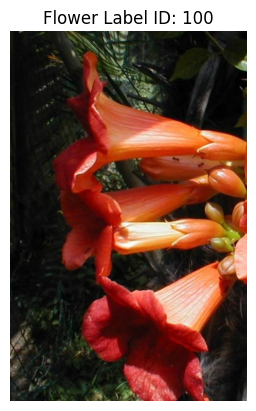

In [3]:
def load_datasets(data_dir='./data'):
    """Downloads and loads all four datasets."""
    datasets = {}
    transform = T.Compose([T.ToTensor()])
    
    print("Loading Flower102...")
    datasets['flowers'] = Flowers102(root=data_dir, split='train', download=True, transform=transform)
    # Note: Flower102 labels are 0-101. For simplicity, we'll just show the label ID.
    
    print("Loading OxfordPets...")
    datasets['pets'] = OxfordIIITPet(root=data_dir, split='trainval', download=True, transform=transform)
    datasets['pets_classes'] = datasets['pets'].classes

    print("Loading CIFAR-10...")
    datasets['cifar10'] = CIFAR10(root=data_dir, train=True, download=True, transform=transform)
    datasets['cifar10_classes'] = datasets['cifar10'].classes

    print("Loading DTD...")
    datasets['dtd'] = DTD(root=data_dir, split='train', download=True, transform=transform)
    datasets['dtd_classes'] = datasets['dtd'].classes
    
    print("All datasets loaded.")
    return datasets

datasets = load_datasets()

def show_image(image_tensor, title=''):
    """Displays a single image tensor."""
    if isinstance(image_tensor, torch.Tensor):
        image = T.ToPILImage()(image_tensor)
    else:  # Already a PIL image
        image = image_tensor
    plt.imshow(image)
    plt.title(title)
    plt.axis('off')
    plt.show()

# Example: Show a random image from the Flowers dataset
sample_idx = random.randint(0, len(datasets['flowers']) - 1)
image, label = datasets['flowers'][sample_idx]
show_image(image, title=f"Flower Label ID: {label}")

## 3. Model Loading

We'll define a function to load a multimodal model and its processor from Hugging Face. We're using `BitsAndBytesConfig` to load the models in 4-bit precision, which significantly reduces memory usage and makes it possible to run these large models on consumer GPUs.

In [13]:
MODEL_IDS = {
    "llava": "llava-hf/llava-1.5-7b-hf",
    #"gemma3": "google/gemma-3-12b-it",
    "gemma3": "google/gemma-3-4b-it",
    "bakllava": "llava-hf/bakLlava-v1-hf",
    "qwen-vl": "Qwen/Qwen2-VL-7B-Instruct",
}

g_model = None
g_processor = None

def load_model_globally(model_name):
    """Loads a specified model and its processor into global variables."""
    global g_model, g_processor
    
    model_id = MODEL_IDS.get(model_name.lower())
    if not model_id:
        raise ValueError(
            f"Unknown model: {model_name}. Available models: {list(MODEL_IDS.keys())}"
        )

    print(f"Loading model: {model_id}...")

    if "gemma" in model_name.lower():
        g_model = Gemma3ForConditionalGeneration.from_pretrained(model_id, torch_dtype=torch.bfloat16).to("cuda")
    elif "qwen2-vl" in model_name.lower() or "qwen-vl" in model_name.lower():
        quantization_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16,
        )
    
        # Qwen requires trusting remote code
        trust_remote_code = "qwen" in model_name.lower()
    
        g_model = Qwen2VLForConditionalGeneration.from_pretrained(
            model_id,
            quantization_config=quantization_config,
            torch_dtype=torch.float16,
            device_map="auto",
            trust_remote_code=trust_remote_code, 
        )

    g_processor = AutoProcessor.from_pretrained(model_id)

    print(f"Model {model_id} loaded successfully.")

## 4. In-Context Learning for Image Classification

This is the core of the notebook. We'll create a function `run_few_shot_inference` that constructs a prompt for a model.

The prompt will contain:
*   A general instruction (e.g., "Classify the following image.")
*   A few "shots" or examples, where each shot is an image paired with its correct label.
*   The final query image that we want the model to classify.

The prompt structure is critical and can differ between models. LLaVA-style models use `<image>` tokens in the text, while PaliGemma has a simpler `\n` separated format.

In [19]:
!pip install qwen-vl-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 MB 4.5 MB/s  0:00:08 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [qwen-vl-utils]


In [31]:
import torch
import torchvision.transforms as T
from qwen_vl_utils import process_vision_info

def run_icl_inference(model, processor, model_name, num_shots, dataset_name):
    """
    Runs In-Context Learning inference handling Qwen vs Gemma differences.
    
    Args:
        model: The loaded model (Qwen2VLForConditionalGeneration or AutoModel).
        processor: The loaded processor.
        model_name: String containing the model name (e.g. "Qwen2-VL-7B").
        shots: List of tuples (image_tensor, label_id).
        query: Tuple of (query_image_tensor, query_label_id).
        class_names: List of strings for label mapping.
    """
    # 2. Get Data
    dataset = datasets[dataset_name]
    class_names = datasets.get(f"{dataset_name}_classes")
    
    indices = random.sample(range(len(dataset)), num_shots + 1)
    shots = [dataset[i] for i in indices[:num_shots]]
    query = dataset[indices[num_shots]]
    
    # --- 1. Common: Build the Message History ---
    # Both models accept the standard OpenAI-style [{"role":..., "content":...}] format
    content_parts = []
    
    # Process Few-Shot Examples
    for img_tensor, label_id in shots:
        img_pil = T.ToPILImage()(img_tensor)
        label_text = class_names[label_id] if class_names else str(label_id)
        
        content_parts.append({"type": "image", "image": img_pil})
        content_parts.append({"type": "text", "text": f"This is an image of a {label_text}.\n"})

    # Process Query Image
    query_img_pil = T.ToPILImage()(query[0])
    content_parts.append({"type": "image", "image": query_img_pil})
    content_parts.append({"type": "text", "text": "Classify the following image."})

    messages = [{"role": "user", "content": content_parts}]

    # --- 2. Branching Logic: Prepare Inputs ---
    
    # >>> BRANCH A: QWEN2-VL <<<
    if "qwen" in model_name.lower():
        # 1. Generate text with special tokens
        text_prompt = processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        
        # 2. Use Qwen Utils to extract images and grid configuration
        image_inputs, video_inputs = process_vision_info(messages)
        
        # 3. Create Inputs
        inputs = processor(
            text=[text_prompt],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        )

    # >>> BRANCH B: GEMMA / STANDARD <<<
    else:
        print("Using Gemma")
        # 1. Generate text prompt
        text_prompt = processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        
        # 2. Manually extract PIL images in order (Gemma needs a flat list)
        # We iterate through content_parts to ensure order matches the text tokens
        all_images_pil = [part["image"] for part in content_parts if part["type"] == "image"]
        
        # 3. Create Inputs
        inputs = processor(
            text=[text_prompt],
            images=all_images_pil,
            padding=True,
            return_tensors="pt",
        )

    # --- 3. Common: Inference ---
    inputs = inputs.to(model.device)
    
    # Generate
    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=128)
    
    # Decode
    # We clip the input tokens to only see the new generated text
    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    
    output_text = processor.batch_decode(
        generated_ids_trimmed, 
        skip_special_tokens=True, 
        clean_up_tokenization_spaces=False
    )

    return output_text[0]

# --- Usage Example ---
result = run_icl_inference(g_model, g_processor, "gemma", 3,"flowers")
print(result)

Using Gemma
This is an image of a 97.


In [10]:
def get_prompt(model_name, shots, query_image, class_names=None):
    """Constructs a model-specific few-shot prompt."""

    # Convert tensors to PIL images
    shot_images = [T.ToPILImage()(shot[0]) for shot in shots]
    query_image_pil = T.ToPILImage()(query_image[0])
    shot_labels = [shot[1] for shot in shots]

    # Use class names if available, otherwise use raw label IDs
    if class_names:
        shot_labels_text = [class_names[l] for l in shot_labels]
    else:
        shot_labels_text = [str(l) for l in shot_labels]

    images = shot_images + [query_image_pil]

    # LLaVA and Qwen use a similar chat format with <image> tokens
    if "llava" in model_name or "qwen" in model_name:
        prompt_text = "You are an expert at image classification. Classify the final image based on the examples provided.\n"
        for i, label_text in enumerate(shot_labels_text):
            prompt_text += f"<image>\nThis is an image of a {label_text}.\n"
        prompt_text += "<image>\nThis is an image of a"

    # Gemma3 uses a different prompt structure
    elif "gemddma-3" in model_name.lower():
        prompt_text = "<start_of_turn>user\n"
        for i, label_text in enumerate(shot_labels_text):
            prompt_text += f"<image>This is an image of a {label_text}.\n"
        prompt_text += "<image>Classify the following image.\n<end_of_turn>\n<start_of_turn>model\n"
        images = shot_images + [query_image_pil]
    else:
        raise ValueError("Unsupported model for prompt creation.")

    return prompt_text, images


def run_inference(model, processor, prompt_text, images):
    """Runs inference on the model with the given prompt and images."""
    inputs = None
    if "gemma" in model.config.name_or_path:
        inputs = processor.apply_chat_template(
            prompt_text,
            tokenize=True,
            return_dict=True,
            return_tensors="pt",
            add_generation_prompt=True,
        ).to(model.device)
    else: 
        inputs = processor(
            text=prompt_text, images=images, return_tensors="pt", padding=True
        ).to(model.device)

    generate_ids = model.generate(**inputs, max_new_tokens=50, cache_implementation="static", do_sample=False)

    # Decode the generated tokens to text
    # Specific decoding is needed for different models
    if "qwen" in processor.tokenizer.name_or_path.lower():
        # Qwen's output can sometimes include the prompt, so we clean it up
        decoded_text = (
            processor.tokenizer.decode(generate_ids[0], skip_special_tokens=True)
            .split("of a")[-1]
            .strip()
        )
    else:
        # For LLaVA and PaliGemma, we remove the prompt from the generated text
        decoded_text = processor.batch_decode(
            generate_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False
        )[0]
        if "gemma" not in model.config.name_or_path:
            if prompt_text in decoded_text:
                 decoded_text = decoded_text.split(prompt_text)[-1].strip()

    return decoded_text


def run_and_display_example(dataset_name, num_shots=3):
    """Main function to run an example and display results."""
    global g_model, g_processor
    
    if g_model is None or g_processor is None:
        print("Please load a model first by running the `load_model_globally` function.")
        return
        
    model_name = g_model.config.name_or_path
    
    print(f"\n{'='*50}")
    print(
        f"Running example for MODEL: {model_name.upper()} on DATASET: {dataset_name.upper()}"
        )
    print(f"{'='*50}\n")
    
    # 2. Get Data
    dataset = datasets[dataset_name]
    class_names = datasets.get(f"{dataset_name}_classes")

    # Select random samples for shots and query
    indices = random.sample(range(len(dataset)), num_shots + 1)
    shots = [dataset[i] for i in indices[:num_shots]]
    query = dataset[indices[num_shots]]
    print(model_name)
    # 3. Create Prompt (with special handling for Gemma3)
    if "gemma" in model_name.lower():
        print("Running FEW-SHOT for Gemma3 with Chat Template.")
        
        # We need to build the "content" list for the chat template
        content_parts = []
        all_images_pil = []

        # --- A. Process Few-Shot Examples ---
        # We assume shots contains tuples of (image_tensor, label_id)
        for shot in shots:
            # Convert tensor to PIL Image (essential for the processor)
            img_pil = T.ToPILImage()(shot[0])
            label_id = shot[1]
            
            # Get the text label
            if class_names:
                label_text = class_names[label_id]
            else:
                label_text = str(label_id)

            # Add Image and Text to the content list
            content_parts.append({"type": "image", "image": img_pil})
            content_parts.append({"type": "text", "text": f"This is an image of a {label_text}.\n"})
            
            # Keep track of the PIL image for the final list
            all_images_pil.append(img_pil)

        # --- B. Process the Query Image ---
        query_img_pil = T.ToPILImage()(query[0])
        all_images_pil.append(query_img_pil)

        # Add query image and the question to content
        content_parts.append({"type": "image", "image": query_img_pil})
        content_parts.append({"type": "text", "text": "Classify the following image."})

        # --- C. Build the Message Structure ---
        messages = [
            {
                "role": "user",
                "content": content_parts
            }
        ]

        # --- D. Generate the Text Prompt ---
        # tokenize=False returns the string with special tokens, not the integers
        print(messages)
        prompt_text = messages
            #g_processor.apply_chat_template(
            #messages, 
            #tokenize=False, 
            #add_generation_prompt=True
        #)

        print("aca",prompt_text)

        # Set the images list that matches the order in 'content_parts'
        images_for_prompt = all_images_pil
    else:
        prompt_text, images_for_prompt = get_prompt(model_name, shots, query, class_names)

    # 4. Display shots and query image
    if "gemma" not in model_name.lower():
        print("--- Few-Shot Examples ---")
        for img, label in shots:
            label_text = class_names[label] if class_names else str(label)
            show_image(img, title=f"Example: {label_text}")

    print("--- Query Image ---")
    query_label_text = class_names[query[1]] if class_names is not None else str(query[1])
    show_image(query[0], title=f"Ground Truth: {query_label_text}")

    # 5. Run Inference
    print("Querying model...")
    print(f'Prompt: \n"{prompt_text}"')

    generated_text = run_inference(g_model, g_processor, prompt_text, images_for_prompt)

    print(f"\n--- Model's Prediction ---")
    print(f"Model Output: '{generated_text}'")

### 5. Load a Model and Run Examples

In [16]:
import ipywidgets as widgets
from IPython.display import display

model_names = list(MODEL_IDS.keys())
model_dropdown = widgets.Dropdown(options=model_names, description='Model:')
load_button = widgets.Button(description='Load Model')

def on_load_button_clicked(b):
    load_model_globally(model_dropdown.value)
#load_button.on_click(on_load_button_clicked)

#display(model_dropdown, load_button)
# "gemma3"
selected_model = 'qwen-vl'
load_model_globally(selected_model)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading model: Qwen/Qwen2-VL-7B-Instruct...


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

model-00001-of-00005.safetensors:   0%|          | 0.00/3.90G [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

Model Qwen/Qwen2-VL-7B-Instruct loaded successfully.


### Example 1: Classifying Pets with LLaVA

In [ ]:
run_and_display_example("pets")

### Example 2: Classifying Textures with Qwen-VL

In [ ]:
run_and_display_example("dtd")

### Example 3: Classifying CIFAR-10 with BakLLaVA (Mistral base)

In [ ]:
run_and_display_example("cifar10")

### Example 4: Zero-Shot with Gemma3

Gemma3's architecture is better suited for simple instruction following (like captioning or VQA) out-of-the-box rather than the complex, interleaved few-shot format of LLaVA. Here we'll do a simpler zero-shot query.

In [17]:
run_and_display_example("flowers")


Running example for MODEL: QWEN/QWEN2-VL-7B-INSTRUCT on DATASET: FLOWERS

Qwen/Qwen2-VL-7B-Instruct


ValueError: Unsupported model for prompt creation.

In [ ]:
run_and_display_example("flowers", num_shots=3)

In [ ]:
!pip install upgrade gemma

In [9]:
import torch
from transformers import pipeline
from PIL import Image

# 1. Define the model ID and pipeline
model_id = "google/gemma-3-4b-it" # Use a 4B, 12B, or 27B model for image support

# Set the pipeline task to "image-text-to-text" for multimodal input
pipe = pipeline(
    task="image-text-to-text",
    model=model_id,
    device="cuda:0" if torch.cuda.is_available() else "cpu", # Use "cuda:0" if GPU is available
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float32
)

# 2. Specify the path to your image file
image_path = "./your_image_file.jpg" # Replace with your actual image file path

# 3. Create the prompt with the image placeholder
# The model uses "<img>" as a token to insert the image data into the prompt
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "url": image_path},
            {"type": "text", "text": "What is shown in this image? Provide a detailed description."}
        ]
    }
]

# 4. Run the pipeline
# The pipeline handles image loading and processing automatically
output = pipe(messages, max_new_tokens=200)

# 5. Print the generated text
print(output[0]["generated_text"][-1]["content"])


`torch_dtype` is deprecated! Use `dtype` instead!


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

KeyboardInterrupt: 